In [113]:
import numpy as np
import pandas as pd
import geopandas as gpd
import geemap,ee
from shapely.geometry import mapping
import os
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib.pyplot as plt
from libpysal.weights import Queen, KNN
from esda.moran import Moran, Moran_Local
from splot.esda import moran_scatterplot, lisa_cluster
import rasterio
import numpy as np
import glob
import os
from rasterio.features import shapes
import geopandas as gpd
from shapely.geometry import shape
from shapely.geometry import Point
from libpysal.weights import lag_spatial
from esda.moran import Moran_Local
import matplotlib.patches as mpatches
from shapely.geometry import box
from shapely import make_valid
import rasterio.mask
from pyproj import Transformer
from rasterio.warp import calculate_default_transform, reproject, Resampling



In [114]:
ee.Authenticate()

True

In [115]:
ee.Initialize(project='diarodgz')

Abrimos el shapefile de Yellowstone National Park.

In [116]:
ynp_path = os.path.join('YELL_tracts', 'YELL_boundary.shp')
ynp = gpd.read_file(ynp_path)

Obtenemos imágenes satelitales de GEE, Sentinel-2.

In [117]:
aoi = geemap.geopandas_to_ee(ynp)

In [118]:
time_sentinel = ['2017-12-31', '2024-12-31']

In [119]:
ynp_fc = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED').filterBounds(aoi).filter(ee.Filter.date(time_sentinel[0],time_sentinel[1])).filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE',10)).median().clip(aoi)
ynp_fc

In [120]:
ynp.centroid

0    POINT (-110.5472 44.59644)
dtype: geometry

In [121]:
Map = geemap.Map(center=[44.59644,-110.5472], zoom=9)
vis_params = {"min": -10, "max": 3000, 'bands': ['B4', 'B3', 'B2'],}

Map.addLayer(ynp_fc, vis_params,name='Yellowstone National Park')
Map

Map(center=[44.59644, -110.5472], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=Searc…

In [122]:
import rasterio

In [123]:
path_ndvi = os.path.join('ndvi_anual', 'ndvi_anual', '2001_NDVI_MNDWI.tif')
ndvi_2001=rasterio.open(path_ndvi)

In [124]:
for i in range(1, ndvi_2001.count + 1):
        print(f"Band {i}: {ndvi_2001.descriptions[i-1]}")

Band 1: NDVI
Band 2: MNDWI


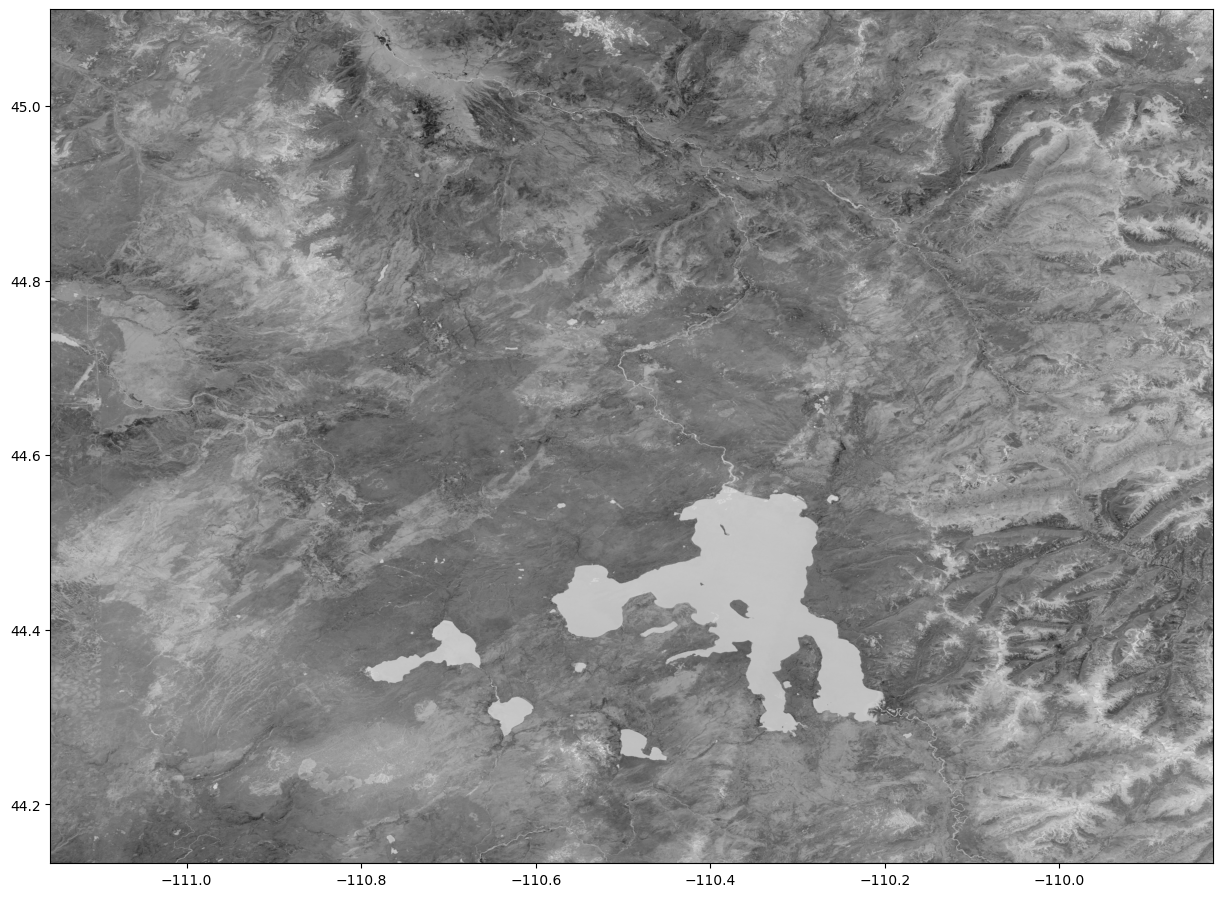

In [126]:
import matplotlib.pyplot as plt
from rasterio.plot import show 

fig=plt.figure(figsize=(15,20))
crs=32719
ax=fig.add_subplot(111)

show(ndvi_2001.read(1),ax=ax, transform=ndvi_2001.transform, cmap='Grays');

# Serie de Tiempo

Calculamos el NDVI promedio por cada año.

In [33]:
ndvi_files = os.listdir(os.path.join('ndvi_anual', 'ndvi_anual'))
records = []

for file in ndvi_files:
    year = file[:4]
    path = os.path.join('ndvi_anual', 'ndvi_anual', file)

    with rasterio.open(path) as src:
        data = src.read(1)
        data = np.where(data == src.nodata, np.nan, data)
        mean_ndvi = np.nanmean(data)
        records.append({"year": year, "mean_ndvi": mean_ndvi})

df = pd.DataFrame(records).sort_values("year").reset_index(drop=True)
print(df)


    year  mean_ndvi
0   2001   0.090747
1   2002   0.124196
2   2003   0.080316
3   2004   0.100945
4   2005   0.090368
5   2006   0.091530
6   2007   0.093215
7   2008   0.097121
8   2009   0.090202
9   2010   0.114680
10  2011   0.088846
11  2012   0.097177
12  2013   0.134784
13  2014   0.110889
14  2015   0.135142
15  2016   0.157222
16  2017   0.138833
17  2018   0.132896
18  2019   0.147370
19  2020   0.138178
20  2021   0.144047
21  2022   0.138395
22  2023   0.155057
23  2024   0.147388


Graficamos la serie de tiempo.

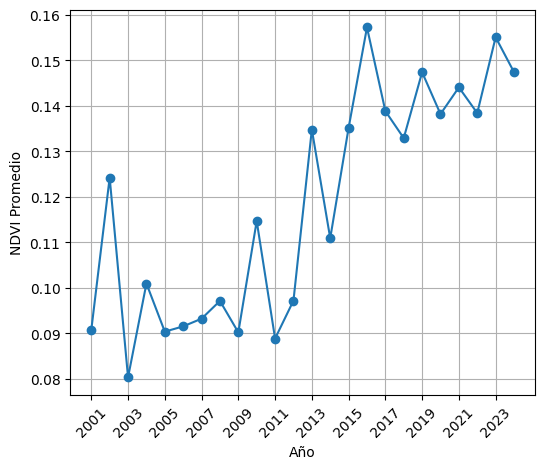

In [9]:
fig, ax = plt.subplots(figsize=[6, 5])

ax.plot(df['year'], df['mean_ndvi'], marker='o')

ax.set_xticks(df['year'][::2])
ax.set_xticklabels(df['year'][::2], rotation=45)

ax.set_xlabel("Año")
ax.set_ylabel("NDVI Promedio")
ax.grid(True)
plt.savefig('ndvi_timeseries.png', dpi=300)

# Creación de GIF del NDVI a lo largo de los años.

In [ ]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio  
from matplotlib import cm

GIF saved to ndvi_time_series.gif


In [140]:


frames = []
folder = "ndvi_reprojected_anual"
files = sorted(os.listdir(folder))

fig, ax = plt.subplots(figsize=(6,6), dpi=100)

# For saving individual PNGs
os.makedirs("ndvi_frames", exist_ok=True)

for i, file in enumerate(files):
    year = file[:4]
    path = os.path.join(folder, file)

    with rasterio.open(path) as src:
        data = src.read(1)
        data = np.where(data == src.nodata, np.nan, data)

    ax.clear()
    img = ax.imshow(data, cmap="YlGn", vmin=0, vmax=1)
    ax.set_title(f"NDVI {year}", fontsize=14)
    ax.axis("off")

    if i == 0:
        cbar = fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("NDVI")

    fig.canvas.draw()
    frame = np.asarray(fig.canvas.renderer.buffer_rgba())[:, :, :3]

    # Save as PNG to verify content
    png_path = f"ndvi_frames/frame_{i:02d}.png"
    plt.savefig(png_path, dpi=100)
    print(f"Saved {png_path}")

    frames.append(frame)

plt.close(fig)

print(f"Collected {len(frames)} frames.")


Saved ndvi_frames/frame_00.png
Saved ndvi_frames/frame_01.png
Saved ndvi_frames/frame_02.png
Saved ndvi_frames/frame_03.png
Saved ndvi_frames/frame_04.png
Saved ndvi_frames/frame_05.png
Saved ndvi_frames/frame_06.png
Saved ndvi_frames/frame_07.png
Saved ndvi_frames/frame_08.png
Saved ndvi_frames/frame_09.png
Saved ndvi_frames/frame_10.png
Saved ndvi_frames/frame_11.png
Saved ndvi_frames/frame_12.png
Saved ndvi_frames/frame_13.png
Saved ndvi_frames/frame_14.png
Saved ndvi_frames/frame_15.png
Saved ndvi_frames/frame_16.png
Saved ndvi_frames/frame_17.png
Saved ndvi_frames/frame_18.png
Saved ndvi_frames/frame_19.png
Saved ndvi_frames/frame_20.png
Saved ndvi_frames/frame_21.png
Saved ndvi_frames/frame_22.png
Saved ndvi_frames/frame_23.png
Collected 24 frames.


In [146]:
png_files = sorted([f"ndvi_frames/{f}" for f in os.listdir("ndvi_frames") if f.endswith(".png")])

frames = [imageio.imread(png) for png in png_files]
imageio.mimsave("ndvi_time_series.gif", frames, duration=0.02, loop=0)

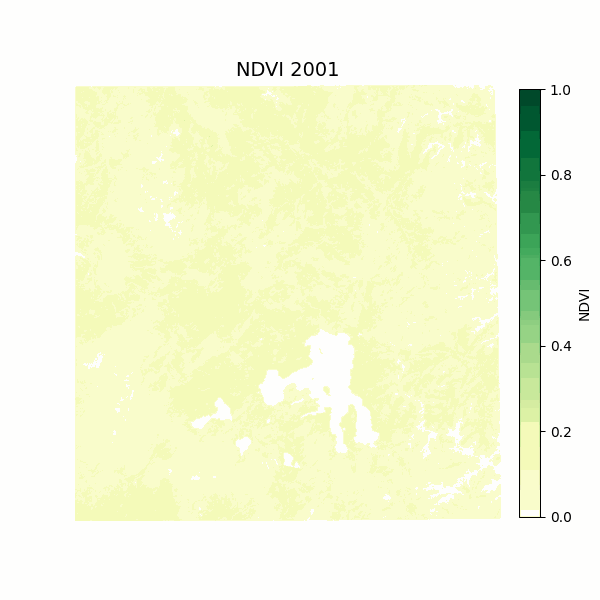

In [151]:
from IPython.display import Image

Image(filename="ndvi_time_series.gif")


# Regresión Lineal en Función del Tiempo

In [66]:
years_int = np.array([int(yr) for yr in df['year'].values]) - int(df['year'][0])

In [67]:
model = np.polyfit(years_int, df['mean_ndvi'].values, 1)
model

array([0.00292053, 0.08472824])

In [68]:
linear_fit = np.polyval(model, years_int)

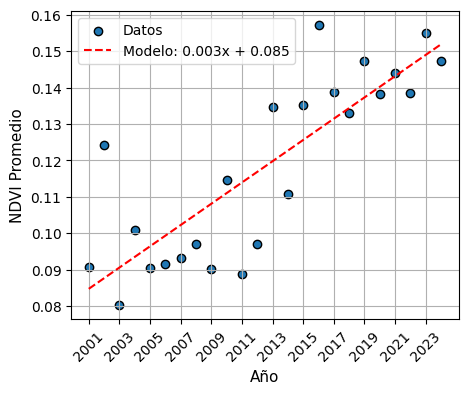

In [150]:
fig, ax = plt.subplots(figsize=[5, 4])

ax.scatter(df['year'], df['mean_ndvi'], marker='o', edgecolors='black', label='Datos')
ax.plot(years_int, linear_fit, ls='--', c='r', label=f'Modelo: {model[0]:.3f}x + {model[1]:.3f}')


ax.set_xticks(df['year'][::2])
ax.set_xticklabels(df['year'][::2], rotation=45)

ax.set_xlabel("Año", fontsize=11)
ax.set_ylabel("NDVI Promedio", fontsize=11)

ax.grid(True)
plt.legend()
plt.savefig('ndvi_fit.png', dpi=300)
